# 06 · Agenda temática: representación, tópicos, estabilidad y puntos de cambio
**Proyecto PLN · Entrega 2** — *¿Qué tan estable es la agenda temática de la prensa colombiana entre 1980 y 2011 y cuándo se producen cambios significativos?*

**Agenda = prevalencia de tópicos** (proporción del corpus dedicada a cada tema en un año).

Orden de trabajo (lo histórico va **al final**, nunca al revés):
1. Representación: BoW → TF‑IDF → embeddings (comparación con criterios explícitos).
2. Modelo base: **NMF** sobre TF‑IDF; K elegido por coherencia NPMI y estabilidad entre semillas.
3. Prevalencia de tópicos por año y por fuente.
4. **Estabilidad**: divergencia Jensen‑Shannon entre años contra un **modelo nulo** (permutaciones estratificadas por fuente) y curva de decaimiento por rezago.
5. **Puntos de cambio**: segmentación binaria con umbral calibrado por permutación.
6. **Robustez**: semilla, K, sin entidades, solo El Tiempo, solo Semana.
7. Contraste con coyunturas históricas (lista congelada antes de ver resultados).
8. Limitaciones encontradas y mejoras propuestas.

Colab gratis (CPU): ~25–40 min con `FAST=False` (los embeddings usan GPU T4 si está activada; si no, solo ~4 000 documentos). `FAST=True` = prueba rápida.

In [ ]:
UTILS_SRC = '"""Utilidades compartidas por los notebooks del proyecto."""\n\nimport hashlib\nimport io\nimport re\nimport urllib.request\nfrom pathlib import Path\n\nimport pandas as pd\n\nCORPUS_URL = "https://github.com/CASDAV/proyecto-pln/releases/download/corpus-v1/noticias_colombia.parquet"\nSHA256 = "92b02aa1a74015192d583cede59c3d8bd7794c214028809cc687704255aa2fc7"\nN_DOCS_UNICOS = 91585\n\n\ndef in_colab() -> bool:\n    try:\n        import google.colab  # noqa: F401\n\n        return True\n    except ImportError:\n        return False\n\n\ndef repo_root() -> Path:\n    for d in [Path.cwd(), *Path.cwd().parents]:\n        if (d / "pyproject.toml").exists():\n            return d\n    return Path.cwd()\n\n\ndef _sha256(path: Path) -> str:\n    h = hashlib.sha256()\n    with path.open("rb") as f:\n        for chunk in iter(lambda: f.read(1 << 20), b""):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef setup(verbose: bool = True) -> None:\n    """Prepara el entorno de ejecución.\n\n    En Colab instala las dependencias que no vienen preinstaladas. En local\n    no instala nada (eso lo resuelve uv o pip). En ambos casos descarga el\n    corpus de stopwords de NLTK si falta.\n    """\n    if in_colab():\n        import subprocess\n        import sys\n\n        paquetes = ["spacy>=3.8", "nltk", "wordcloud", "pyarrow"]\n        if verbose:\n            print("Instalando dependencias en Colab...")\n        subprocess.run(\n            [sys.executable, "-m", "pip", "install", "-q", *paquetes], check=True\n        )\n\n    import nltk\n\n    try:\n        nltk.data.find("corpora/stopwords")\n    except LookupError:\n        nltk.download("stopwords", quiet=not verbose)\n\n\ndef load_corpus_raw(verify: bool = True) -> pd.DataFrame:\n    """Carga el corpus crudo, sin deduplicación ni limpieza.\n\n    Colab: descarga a memoria en cada sesión.\n    Local: descarga una vez a data/ y reutiliza el archivo.\n    """\n    if in_colab():\n        blob = urllib.request.urlopen(CORPUS_URL).read()\n        got = hashlib.sha256(blob).hexdigest()\n        if got != SHA256:\n            raise RuntimeError(f"checksum no coincide: {got}")\n        return pd.read_parquet(io.BytesIO(blob))\n\n    dest = repo_root() / "data" / "noticias_colombia.parquet"\n\n    if not dest.exists():\n        dest.parent.mkdir(parents=True, exist_ok=True)\n        tmp = dest.with_suffix(".part")\n        urllib.request.urlretrieve(CORPUS_URL, tmp)\n        got = _sha256(tmp)\n        if got != SHA256:\n            tmp.unlink()\n            raise RuntimeError(f"checksum no coincide: {got}")\n        tmp.rename(dest)\n    elif verify and _sha256(dest) != SHA256:\n        raise RuntimeError(f"archivo corrupto en {dest}")\n\n    return pd.read_parquet(dest)\n\n\ndef load_corpus(verify: bool = True) -> pd.DataFrame:\n    """Corpus deduplicado (criterio de 01-corpus) y con `fecha` parseada.\n\n    Descarta duplicados por texto normalizado: minúsculas, espacios\n    colapsados y recortados. Verifica el conteo esperado de documentos.\n    """\n    df_raw = load_corpus_raw(verify=verify)\n\n    norm = df_raw["texto"].str.lower().str.replace(r"\\s+", " ", regex=True).str.strip()\n\n    df = df_raw[~norm.duplicated()].reset_index(drop=True).copy()\n    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")\n\n    if len(df) != N_DOCS_UNICOS:\n        raise RuntimeError(f"esperaba {N_DOCS_UNICOS} documentos, hay {len(df)}")\n\n    return df\n\n\ndef results_dir() -> Path:\n    """Carpeta de resultados: /content/results en Colab, results/ del repo en local."""\n    d = (Path("/content") if in_colab() else repo_root()) / "results"\n    d.mkdir(parents=True, exist_ok=True)\n    return d\n\n\nRE_MILES = re.compile(r"(?<!\\d)(\\d{1,3})(?: [\'’] | \\. )(?=\\d{3}(?!\\d))")\nRE_DEC_COMA = re.compile(r"(?<=\\d) , (?=\\d{1,2}(?!\\d))")\nRE_DEC_PUNTO = re.compile(r"(?<=\\d) \\. (?=\\d{1,2}(?!\\d)(?! *:))")\nRE_AMPM = re.compile(r"(?<=\\d)\\s+([ap])\\s*\\.?\\s+m\\b")\nRE_CTRL = re.compile(r"[\\x80-\\x9f]")\n\n\ndef normalizar_texto(s: pd.Series) -> pd.Series:\n    """Reune cifras y horas que la tokenización de origen partió con espacios."""\n    return (\n        s.str.replace(RE_CTRL, " ", regex=True)\n        .str.replace(RE_MILES, r"\\1", regex=True)\n        .str.replace(RE_DEC_COMA, ",", regex=True)\n        .str.replace(RE_DEC_PUNTO, ".", regex=True)\n        .str.replace(RE_AMPM, r" \\1m", regex=True)\n    )\n'

In [ ]:
import os, sys, re, json, time, warnings, random
from collections import Counter, defaultdict
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 80)

# utils.py (del repo). Si no está junto al notebook, se crea una copia idéntica.
try:
    import utils
except ImportError:
    open("utils.py", "w", encoding="utf-8").write(UTILS_SRC)
    import utils

try:
    import nltk
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOP = set(stopwords.words("spanish"))
except Exception as e:
    print("NLTK no disponible, uso lista de respaldo:", e)
    STOP = set("""de la que el en y a los del se las por un para con no una su al lo como más pero sus le ya o este sí porque esta entre cuando muy sin sobre también me hasta hay donde quien desde todo nos durante todos uno les ni contra otros ese eso ante ellos e esto mí antes algunos qué unos yo otro otras otra él tanto esa estos mucho quienes nada muchos cual poco ella estar estas algunas algo nosotros mi mis tú te ti tu tus ellas nosotras vosotros vosotras os mío mía míos mías tuyo tuya suyo suya nuestro nuestra es son fue ha han ser era está están sido será fueron he hemos había sea fue""".split())
EXTRA_STOP = set("""dijo año años así ayer hoy además según cada tras sino parte mismo mismos misma puede pueden hacer hace hizo dos tres cuatro cinco mil millones pesos ser va van sido ahora aquí allí bien todavía menos mayor primer primera segundo segunda""".split())
STOP |= EXTRA_STOP

RE_TOK = re.compile(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+|[.?!]")
TERM = {".", "?", "!"}

def tokenizar(texto):
    """Devuelve (tokens_todos, tokens_contenido, entidades).
    tokens_todos: minúsculas, sin puntuación (para colocaciones).
    tokens_contenido: sin stopwords y len>=3.
    entidades: palabras con mayúscula inicial que no abren oración (proxy de nombres propios)."""
    todos, cont, ent = [], [], []
    inicio = True
    for t in RE_TOK.findall(texto):
        if t in TERM:
            inicio = True
            continue
        low = sys.intern(t.lower())
        todos.append(low)
        es_cont = len(low) >= 3 and low not in STOP
        if es_cont:
            cont.append(low)
            if t[0].isupper() and not inicio and not t.isupper():
                ent.append(low)
        inicio = False
    return todos, cont, ent

def savefig(name, results):
    plt.tight_layout()
    plt.savefig(results / name, dpi=130)
    plt.show()

In [ ]:
FAST = False
SEED = 42
CAP_PER_YEAR = 80 if FAST else 1000       # documentos por año para AJUSTAR vectorizador y NMF (balanceo temporal)
MIN_N = 20 if FAST else 40                # mínimo de documentos por año para analizar ese año (el nulo calibra el ruido según N)
B_PERM = 100 if FAST else 1000            # permutaciones del modelo nulo
KS = [4, 6, 8] if FAST else [15, 20, 30, 40]
K_OVERRIDE = None                         # fija K manualmente si se desea
N_EMB_PER_YEAR = 15 if FAST else 150      # documentos por año para comparar embeddings
USE_EMB = True
EMB_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
MIN_DF, MAX_DF, MAX_FEAT = (3, 0.5, 5000) if FAST else (15, 0.4, 25000)
rng = np.random.default_rng(SEED)

## 1. Carga y preprocesamiento
Mismo preprocesamiento que el notebook 05. Se crean dos vistas del texto: con entidades y **sin entidades** (palabras que en ≥50 % de sus apariciones aparecen en mayúscula a mitad de oración), para la prueba de robustez.

In [ ]:
results = utils.results_dir()
df = utils.load_corpus()
df["texto_limpio"] = utils.normalizar_texto(df["texto"])
df["año"] = df["fecha"].dt.year
df = df.dropna(subset=["fecha"])
df = df[(df["año"] >= 1980) & (df["año"] <= 2011)].reset_index(drop=True)
if FAST: df = df.sample(min(len(df), 6000), random_state=SEED).reset_index(drop=True)
print(len(df), "documentos")
t0 = time.time()
cont, ent_c, uni = [], Counter(), Counter()
for txt in df["texto_limpio"].values:
    _, c, e = tokenizar(txt)
    cont.append(c); uni.update(c); ent_c.update(e)
ENT_WORDS = {w for w, k in ent_c.items() if uni[w] >= 5 and k / uni[w] >= 0.5}
print(f"Tokenizado en {time.time()-t0:.0f}s | palabras-entidad: {len(ENT_WORDS):,} ({sum(uni[w] for w in ENT_WORDS)/sum(uni.values()):.1%} de los tokens)")
docs_full = [" ".join(c) for c in cont]
docs_noent = [" ".join(w for w in c if w not in ENT_WORDS) for c in cont]
del cont
df["fuente"] = df["fuente"].str.replace(r"^www\.|\.com$", "", regex=True)   # www.eltiempo.com -> eltiempo
years = df["año"].values; srcs = df["fuente"].values
YEARS = np.arange(1980, 2012)
n_y = pd.Series(years).value_counts().reindex(YEARS, fill_value=0)
print(pd.crosstab(df["año"], df["fuente"]).T.to_string())

91585 documentos
Tokenizado en 29s | palabras-entidad: 22,683 (14.9% de los tokens)
año       1980  1982  1983  1984  1985  1986  1987  1988  1989  1990  1991  1992  1993  1994  1995  1996  1997  1998  1999  2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010  2011
fuente                                                                                                                                                                                            
dinero       0     0     0     0     0     0     0     0     0     0     0     0    13    20    32     0     9    47    48    66    56    39    75    85   167   269   560   548   532   668   192
eltiempo     0     0     0     0     0     0     0     0     0   807  2355  3093  3359  3167  3802  5445  4903  4951  2231  4657  3966  2877  4053  4425  3008  2358  3803  4909  5291  4609  3470
semana      31    58   166    71    47    53    57    69    91    84    94   111   128   137   144   201   158   151   155   193   240  

In [ ]:
# Muestra balanceada por año para ajustar (evita que 2000–2011 de El Tiempo domine la estructura)
F_idx = np.concatenate([rng.permutation(np.where(years == y)[0])[:CAP_PER_YEAR] for y in YEARS if (years == y).any()])
print("Documentos de ajuste:", len(F_idx))

Documentos de ajuste: 22534


## 2. Representaciones: BoW, TF‑IDF y embeddings
**Qué se compara y con qué criterios:** (a) capacidad de separar *periodo* y *fuente* (macro‑F1 con validación cruzada), (b) dimensión/coste, (c) interpretabilidad, (d) viabilidad en Colab gratis.
Advertencia: el periodo está correlacionado con la fuente (años 80 ≈ Semana), por eso se reportan ambos objetivos y se interpreta con cautela.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
tfidf = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=MIN_DF, max_df=MAX_DF,
                        max_features=MAX_FEAT, sublinear_tf=True)
tfidf.fit([docs_full[i] for i in F_idx])
X_all = tfidf.transform(docs_full).tocsr()
feat = np.array(tfidf.get_feature_names_out())
print("TF‑IDF:", X_all.shape, "| densidad: %.3f%%" % (100 * X_all.nnz / (X_all.shape[0] * X_all.shape[1])))
# ejemplo documento -> vector
i = int(np.where(years == 2005)[0][0]) if (years == 2005).any() else 0
bow = CountVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, vocabulary=tfidf.vocabulary_).fit_transform([docs_full[i]])
row = X_all[i]; top = np.argsort(-row.toarray().ravel())[:10]
print("\nDOC", df.id[i], df.fuente[i], df.fecha[i].date())
print("Texto:", df.texto_limpio[i][:300], "...")
print("BoW  : %d términos no nulos de %d (%.2f%% densidad); conteos: %s" % (bow.nnz, bow.shape[1], 100*bow.nnz/bow.shape[1], dict(zip(feat[bow.indices[:6]], bow.data[:6]))))
print("TF‑IDF top:", [(feat[j], round(row[0, j], 3)) for j in top])

TF‑IDF: (91585, 22196) | densidad: 0.518%

DOC 13312 dinero 2005-04-01
Texto: Empleo : ¿ cuestión de ley ?

En estos días se va a iniciar el debate acerca de la conveniencia de mantener vigente la ley laboral 789 de 2002 , mediante la cual se flexibilizó el mercado laboral para estimular la generación y formalización del empleo en el país .
En la misma ley quedó estipulado qu ...
BoW  : 186 términos no nulos de 22196 (0.84% densidad); conteos: {'acerca': np.int64(1), 'actuar': np.int64(1), 'ahí': np.int64(1), 'alternativas': np.int64(1), 'amplió': np.int64(1), 'andes': np.int64(1)}
TF‑IDF top: [('empleo', np.float64(0.178)), ('laboral', np.float64(0.16)), ('ley', np.float64(0.15)), ('reforma', np.float64(0.145)), ('trabajadores', np.float64(0.131)), ('puestos', np.float64(0.126)), ('vigente', np.float64(0.115)), ('debate', np.float64(0.114)), ('trabajo', np.float64(0.103)), ('calidad', np.float64(0.101))]


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
S_idx = np.concatenate([rng.permutation(np.where(years == y)[0])[:N_EMB_PER_YEAR] for y in YEARS if (years == y).any()])
per = pd.cut(years[S_idx], [1979, 1989, 1999, 2005, 2011], labels=["80-89", "90-99", "00-05", "06-11"]).astype(str)
fte = srcs[S_idx]
def cv_f1(model, Z, y, folds=5):
    vc = pd.Series(y).value_counts(); keep = np.isin(y, vc[vc >= folds].index)
    if keep.sum() < 30 or len(set(y[keep])) < 2: return np.nan
    return cross_val_score(model, Z[keep], y[keep], cv=StratifiedKFold(folds, shuffle=True, random_state=SEED), scoring="f1_macro").mean()
res_rep = []
Xs = X_all[S_idx]
res_rep.append(["TF‑IDF disperso (%d dim)" % Xs.shape[1], cv_f1(LinearSVC(), Xs, per), cv_f1(LinearSVC(), Xs, fte), 0.0])
t = time.time(); Zs = TruncatedSVD(min(20 if FAST else 128, Xs.shape[1] - 1), random_state=SEED).fit_transform(Xs); ts = time.time() - t
res_rep.append(["TF‑IDF + SVD (%d dim)" % Zs.shape[1], cv_f1(LogisticRegression(max_iter=2000), Zs, per), cv_f1(LogisticRegression(max_iter=2000), Zs, fte), ts])
EMB = None
if USE_EMB:
    try:
        try:
            from sentence_transformers import SentenceTransformer
        except ImportError:
            import subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"], check=True)
            from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(EMB_MODEL); model.max_seq_length = 128
        t = time.time()
        EMB = model.encode([df.texto_limpio[j][:700] for j in S_idx], batch_size=64, show_progress_bar=False, normalize_embeddings=True)
        te = time.time() - t
        res_rep.append(["Embeddings %s (%d dim)" % (EMB_MODEL.split("-")[-2] if False else "MiniLM‑L12 multiling.", EMB.shape[1]),
                        cv_f1(LogisticRegression(max_iter=2000), EMB, per), cv_f1(LogisticRegression(max_iter=2000), EMB, fte), te])
    except Exception as e:
        print("Embeddings omitidos (sin sentence-transformers/modelo):", repr(e)[:150])
rep = pd.DataFrame(res_rep, columns=["representación", "macroF1 periodo", "macroF1 fuente", "seg. cómputo (muestra)"]).round(3)
print("Muestra:", len(S_idx), "documentos"); print(rep.to_string(index=False))
rep.to_csv(results / "comparacion_representaciones.csv", index=False)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Muestra: 3927 documentos
                            representación  macroF1 periodo  macroF1 fuente  seg. cómputo (muestra)
               TF‑IDF disperso (22196 dim)            0.558           0.527                   0.000
                    TF‑IDF + SVD (128 dim)            0.448           0.495                   1.690
Embeddings MiniLM‑L12 multiling. (384 dim)            0.390           0.439                  10.078


**Lectura esperada.** Los embeddings densos capturan semántica (sinónimos), pero son opacos y costosos sobre 91 k documentos; TF‑IDF es disperso, interpretable (cada dimensión es una palabra) y es la entrada natural de NMF, cuyos tópicos son directamente legibles. Por eso el **modelo base usa TF‑IDF + NMF** y los embeddings se proponen como mejora (BERTopic/clustering sobre embeddings, notebook futuro).

## 3. NMF: elección de K
Para cada K ∈ `KS` y dos semillas: coherencia **NPMI** media (top‑10 palabras, co‑ocurrencia a nivel documento sobre la muestra de ajuste) y **estabilidad entre semillas** (similitud coseno media entre tópicos emparejados con asignación húngara — 1 = idénticos).

In [ ]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
X_F = X_all[F_idx]
Xb = (X_F > 0).astype(np.float32).tocsc(); D_F = Xb.shape[0]; dfreq = np.asarray(Xb.sum(0)).ravel()
def npmi_coh(H, topn=10):
    sc = []
    for k in range(H.shape[0]):
        top = np.argsort(-H[k])[:topn]; sub = Xb[:, top]; co = (sub.T @ sub).toarray()
        s = []
        for a in range(topn):
            for b in range(a + 1, topn):
                pab = co[a, b] / D_F
                s.append(-1.0 if pab == 0 else np.log(pab / ((dfreq[top[a]] / D_F) * (dfreq[top[b]] / D_F))) / (-np.log(pab)))
        sc.append(np.mean(s))
    return np.array(sc)
def estab(Ha, Hb):
    A = Ha / np.linalg.norm(Ha, axis=1, keepdims=True); Bm = Hb / np.linalg.norm(Hb, axis=1, keepdims=True)
    S = A @ Bm.T; r, c = linear_sum_assignment(-S); return S[r, c].mean()
fits = {}
rows = []
for K in KS:
    for seed in (0, 1):
        t = time.time()
        m = NMF(n_components=K, init="nndsvda" if seed == 0 else "random", random_state=seed, max_iter=150, tol=1e-3)
        W = m.fit_transform(X_F); fits[(K, seed)] = (m, W)
    c0 = npmi_coh(fits[(K, 0)][0].components_); c1 = npmi_coh(fits[(K, 1)][0].components_)
    rows.append({"K": K, "coherencia_NPMI": (c0.mean() + c1.mean()) / 2, "coh_min_topico": c0.min(),
                 "estabilidad_semillas": estab(fits[(K, 0)][0].components_, fits[(K, 1)][0].components_),
                 "error_reconstruccion": fits[(K, 0)][0].reconstruction_err_})
    print(f"K={K} listo ({time.time()-t:.0f}s)")
selK = pd.DataFrame(rows).round(4); print(selK.to_string(index=False)); selK.to_csv(results / "seleccion_K.csv", index=False)
ok = selK[selK.estabilidad_semillas >= selK.estabilidad_semillas.median()]
K_STAR = int(K_OVERRIDE or ok.sort_values("coherencia_NPMI", ascending=False).K.iloc[0])
print("K elegido:", K_STAR, "(máxima coherencia entre los K con estabilidad ≥ mediana)")

K=15 listo (7s)
K=20 listo (20s)
K=30 listo (26s)
K=40 listo (55s)
 K  coherencia_NPMI  coh_min_topico  estabilidad_semillas  error_reconstruccion
15           0.2840          0.2121                0.7865              147.0082
20           0.2908          0.1676                0.8115              146.6858
30           0.2967          0.1522                0.8281              146.1080
40           0.3007          0.1457                0.8248              145.6259
K elegido: 40 (máxima coherencia entre los K con estabilidad ≥ mediana)


In [ ]:
nmf, W_F0 = fits[(K_STAR, 0)]
H = nmf.components_
def tabla_topicos(H, n=10):
    return [" ".join(feat[np.argsort(-H[k])[:n]]) for k in range(H.shape[0])]
TOP = tabla_topicos(H)
topic_names = [f"T{k:02d}: " + " ".join(feat[np.argsort(-H[k])[:3]]) for k in range(K_STAR)]
for k in range(K_STAR): print(f"T{k:02d} |", TOP[k])
pd.DataFrame({"topico": topic_names, "top_terminos": TOP}).to_csv(results / "topicos.csv", index=False)

T00 | tan cómo vez tener mejor siempre debe decir tiempo cosas
T01 | ciento crecimiento aumento trimestre incremento cifra período inflación cifras meses
T02 | paz derechos proceso humanos gobierno conflicto violencia guerrilla grupos guerra
T03 | alcalde ciudad alcaldía concejo bogotá administración distrital municipal municipio distrito
T04 | torneo final mundial ganó campeón tenis título campeonato clasificación vuelta
T05 | farc ejército militares guerrilleros militar fuerzas guerrilla brigada comandante eln
T06 | unidos estadounidense washington irak países bush guerra onu naciones estadounidenses
T07 | música disco teatro musical grupo canciones concierto rock festival cantante
T08 | corte justicia fiscalía suprema tribunal juez penal caso fallo investigación
T09 | calle carrera avenida vehículos tránsito sur calles vía norte transporte
T10 | bolsa puntos índice acciones valores alza cerró mercado subió ciento
T11 | empresa compañía empresas energía firma venta servicio gerente t

In [ ]:
# Proyección de todos los documentos a los tópicos y normalización a composición (theta suma 1)
t = time.time(); W_all = nmf.transform(X_all); print(f"transform: {time.time()-t:.0f}s")
rs = W_all.sum(1); ok_doc = rs > 0
theta = np.zeros_like(W_all, dtype=np.float64); theta[ok_doc] = W_all[ok_doc] / rs[ok_doc, None]
print("Documentos sin ningún tópico (vector vacío):", (~ok_doc).sum(), "→ se excluyen del análisis")
dom = theta.argmax(1)
print("Cuota de documentos por tópico dominante:", np.bincount(dom[ok_doc], minlength=K_STAR) / ok_doc.sum())

transform: 5s
Documentos sin ningún tópico (vector vacío): 0 → se excluyen del análisis
Cuota de documentos por tópico dominante: [0.00378883 0.02563739 0.01490419 0.0095758  0.02730797 0.01985041
 0.02462194 0.01047115 0.02876017 0.01577769 0.00800349 0.0234973
 0.01871486 0.02137905 0.01116995 0.02170661 0.03295299 0.00563411
 0.02295136 0.01799421 0.03564994 0.02806136 0.02355189 0.01910793
 0.03311678 0.03110771 0.04780259 0.02225255 0.04654692 0.00811268
 0.02017798 0.03735328 0.02890211 0.02464377 0.03268002 0.04462521
 0.03623956 0.03429601 0.03724409 0.04382814]


## 4. Agenda: prevalencia de tópicos por año y por fuente
Prevalencia del tópico *k* en el año *t* = media de θ_k sobre los documentos del año (composición). Las filas por año suman 1.

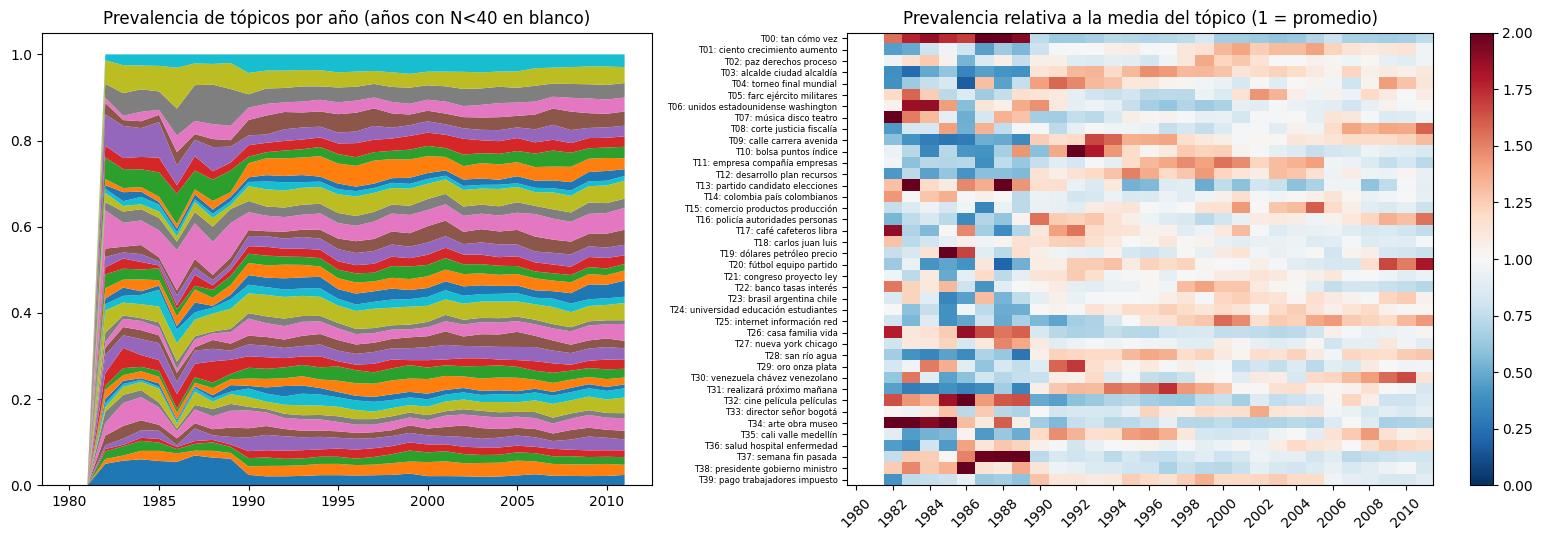

Documentos por año: {1980: 31, 1981: 0, 1982: 58, 1983: 166, 1984: 71, 1985: 47, 1986: 53, 1987: 57, 1988: 69, 1989: 91, 1990: 891, 1991: 2449, 1992: 3204, 1993: 3500, 1994: 3324, 1995: 3978, 1996: 5646, 1997: 5070, 1998: 5149, 1999: 2434, 2000: 4916, 2001: 4262, 2002: 3131, 2003: 4430, 2004: 4853, 2005: 3400, 2006: 2980, 2007: 4703, 2008: 5878, 2009: 6351, 2010: 5918, 2011: 4475}


In [ ]:
def prevalence(mask):
    P = pd.DataFrame(theta[mask & ok_doc]); P["año"] = years[mask & ok_doc]
    return P.groupby("año").mean().reindex(YEARS)
P_all = prevalence(np.ones(len(df), bool)); n_ok = pd.Series(years[ok_doc]).value_counts().reindex(YEARS, fill_value=0)
P_all.columns = topic_names
P_all.round(4).to_csv(results / "prevalencia_topicos_por_anio.csv")
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1, 1.2]})
Pm = P_all.copy(); Pm[n_ok < MIN_N] = np.nan
ax[0].stackplot(YEARS, Pm.fillna(0).T.values, labels=topic_names); ax[0].set_title("Prevalencia de tópicos por año (años con N<%d en blanco)" % MIN_N)
ax[0].legend(fontsize=6, ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1)) if False else None
im = ax[1].imshow((Pm / Pm.mean()).T.values, aspect="auto", cmap="RdBu_r", vmin=0, vmax=2)
ax[1].set_yticks(range(K_STAR)); ax[1].set_yticklabels(topic_names, fontsize=6); ax[1].set_xticks(range(0, 32, 2)); ax[1].set_xticklabels(YEARS[::2], rotation=45)
ax[1].set_title("Prevalencia relativa a la media del tópico (1 = promedio)"); plt.colorbar(im, ax=ax[1])
savefig("fig_prevalencia_topicos.png", results)
print("Documentos por año:", n_ok.to_dict())

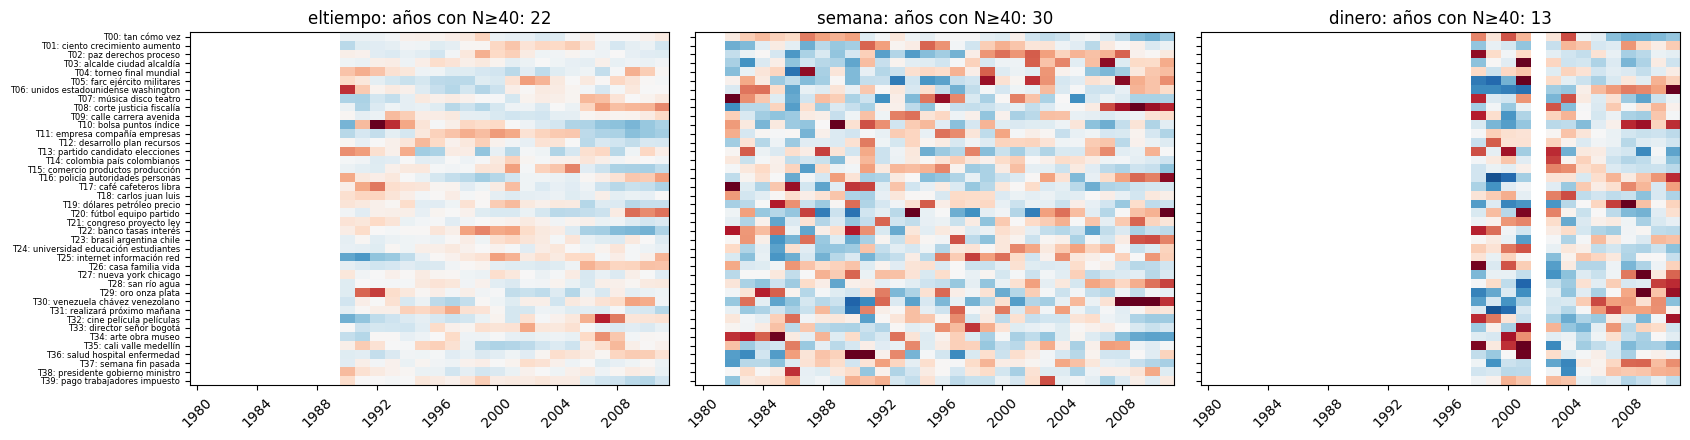

η² (varianza de θ explicada), ponderado por tópico → año: 0.004 | fuente: 0.006


In [ ]:
# Por fuente (solo años con N suficiente en esa fuente)
fig, axs = plt.subplots(1, 3, figsize=(17, 4.5), sharey=True)
P_src = {}
for ax, f in zip(axs, ["eltiempo", "semana", "dinero"]):
    m = srcs == f
    P = prevalence(m); n = pd.Series(years[m & ok_doc]).value_counts().reindex(YEARS, fill_value=0)
    P[n < MIN_N] = np.nan; P_src[f] = (P, n)
    ax.imshow((P / P.mean()).T.values, aspect="auto", cmap="RdBu_r", vmin=0, vmax=2)
    ax.set_title(f"{f}: años con N≥{MIN_N}: {(n>=MIN_N).sum()}"); ax.set_xticks(range(0, 32, 4)); ax.set_xticklabels(YEARS[::4], rotation=45)
axs[0].set_yticks(range(K_STAR)); axs[0].set_yticklabels(topic_names, fontsize=6)
savefig("fig_prevalencia_por_fuente.png", results)
# ¿Cuánto del reparto de tópicos lo explica la fuente frente al año?
def eta2(groups, T):
    tot = ((T - T.mean(0)) ** 2).sum(0); g = pd.DataFrame(T).groupby(groups).transform("mean").values
    return (((g - T.mean(0)) ** 2).sum(0) / tot)
Tm = theta[ok_doc]; w_t = Tm.mean(0)
e_year = eta2(years[ok_doc], Tm); e_src = eta2(srcs[ok_doc], Tm)
print("η² (varianza de θ explicada), ponderado por tópico → año: %.3f | fuente: %.3f" % ((e_year * w_t).sum() / w_t.sum(), (e_src * w_t).sum() / w_t.sum()))

## 5. ¿Qué tan estable es la agenda? Divergencia entre años contra un modelo nulo
**Problema que se corrige (Entrega 1):** una divergencia Jensen‑Shannon entre dos años siempre es > 0 por ruido de muestreo, y es mayor cuanto menos documentos haya. Aquí se compara el valor observado con la distribución nula obtenida **permutando las etiquetas de año entre los documentos de cada par, dentro de cada fuente** (así la composición por fuente queda fija y solo se prueba cambio *dentro* de la fuente). Se reporta p‑valor (corregido por Benjamini–Hochberg) y exceso sobre el piso de ruido.

In [ ]:
def js_div(p, q):
    p = np.clip(p, 1e-12, None); q = np.clip(q, 1e-12, None); p = p / p.sum(); q = q / q.sum(); m = 0.5 * (p + q)
    return 0.5 * (p * np.log2(p / m)).sum() + 0.5 * (q * np.log2(q / m)).sum()

def bh(p):
    p = np.asarray(p); n = len(p); o = np.argsort(p); q = np.empty(n); prev = 1.0
    for rank, i in zip(range(n, 0, -1), o[::-1]):
        prev = min(prev, p[i] * n / rank); q[i] = prev
    return q

def transiciones(mask, lag=1, B=B_PERM, min_n=MIN_N, seed=0):
    rg = np.random.default_rng(seed); m = mask & ok_doc
    idx = {y: np.where(m & (years == y))[0] for y in YEARS}
    out = []
    for y in YEARS:
        y2 = y + lag
        if y2 > 2011 or len(idx[y]) < min_n or len(idx[y2]) < min_n: continue
        a, b = idx[y], idx[y2]; pooled = np.concatenate([a, b]); Th = theta[pooled]
        lab = np.r_[np.zeros(len(a)), np.ones(len(b))]; groups = [np.where(srcs[pooled] == f)[0] for f in np.unique(srcs[pooled])]
        obs = js_div(theta[a].mean(0), theta[b].mean(0)); tot = Th.sum(0); n0, n1 = len(a), len(b); nulls = np.empty(B)
        for r in range(B):
            lp = lab.copy()
            for g in groups: lp[g] = rg.permutation(lab[g])
            s1 = Th.T @ lp; nulls[r] = js_div((tot - s1) / n0, s1 / n1)
        out.append({"año": y, "año2": y2, "n1": n0, "n2": n1, "js": obs, "nulo_media": nulls.mean(), "nulo_p95": np.quantile(nulls, .95),
                    "exceso": obs - nulls.mean(), "z": (obs - nulls.mean()) / (nulls.std() + 1e-12), "p": (1 + (nulls >= obs).sum()) / (B + 1)})
    r = pd.DataFrame(out)
    if len(r): r["p_bh"] = bh(r["p"].values)
    return r

t = time.time()
TR = {"todas": transiciones(np.ones(len(df), bool)), "eltiempo": transiciones(srcs == "eltiempo"), "semana": transiciones(srcs == "semana")}
print(f"{time.time()-t:.0f}s")
for k, r in TR.items():
    if len(r): print(f"{k}: {len(r)} transiciones evaluadas; significativas (BH 5%): {(r.p_bh < .05).sum()} ({(r.p_bh < .05).mean():.0%}); JS medio {r.js.mean():.4f} vs ruido medio {r.nulo_media.mean():.4f}")
r = TR["todas"]; r.round(5).to_csv(results / "transiciones_anuales.csv", index=False)
print(r.sort_values("exceso", ascending=False).head(10)[["año", "año2", "n1", "n2", "js", "nulo_media", "exceso", "z", "p_bh"]].round(4).to_string(index=False))

19s
todas: 29 transiciones evaluadas; significativas (BH 5%): 21 (72%); JS medio 0.0106 vs ruido medio 0.0093
eltiempo: 21 transiciones evaluadas; significativas (BH 5%): 21 (100%); JS medio 0.0029 vs ruido medio 0.0008
semana: 29 transiciones evaluadas; significativas (BH 5%): 4 (14%); JS medio 0.0189 vs ruido medio 0.0146
 año  año2   n1   n2     js  nulo_media  exceso       z   p_bh
1986  1987   53   57 0.0469      0.0326  0.0143  1.8291 0.0685
1982  1983   58  166 0.0283      0.0203  0.0080  1.4895 0.0995
1985  1986   47   53 0.0424      0.0360  0.0064  0.7208 0.2704
1990  1991  891 2449 0.0061      0.0021  0.0039  7.5259 0.0014
2005  2006 3400 2980 0.0048      0.0011  0.0037 14.6665 0.0014
1994  1995 3324 3978 0.0041      0.0007  0.0034 20.2517 0.0014
2008  2009 5878 6351 0.0036      0.0004  0.0032 33.5485 0.0014
2001  2002 4262 3131 0.0038      0.0007  0.0030 16.8106 0.0014
1991  1992 2449 3204 0.0035      0.0009  0.0026 11.4003 0.0014
2007  2008 4703 5878 0.0030      0.0005  0.0

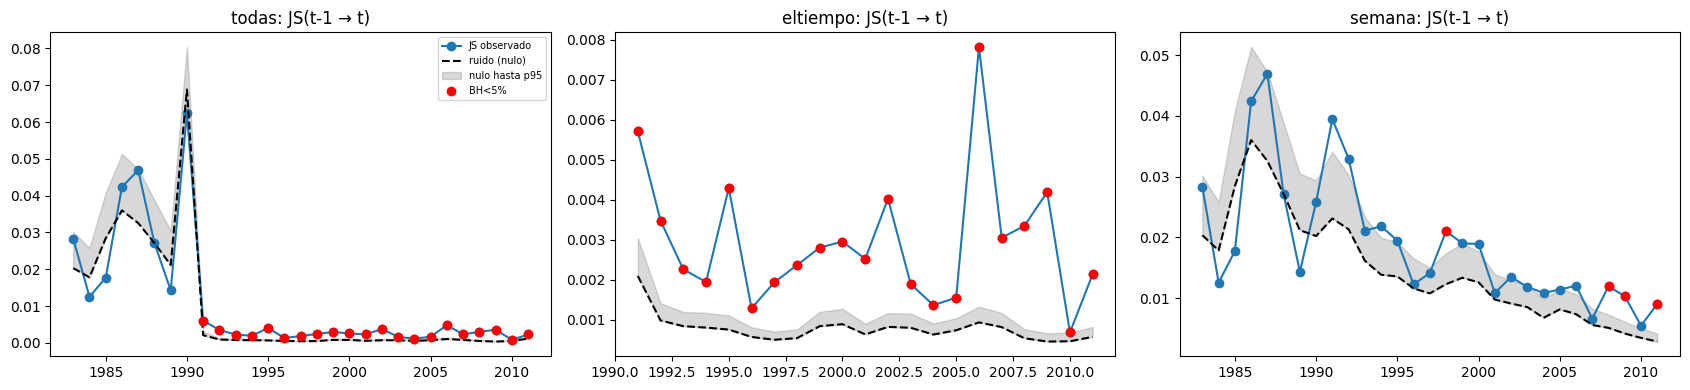

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4), sharey=False)
for ax, (k, r) in zip(axs, TR.items()):
    if not len(r): ax.set_title(k + ": sin datos"); continue
    ax.plot(r["año2"], r["js"], "o-", label="JS observado"); ax.plot(r["año2"], r["nulo_media"], "k--", label="ruido (nulo)")
    ax.fill_between(r["año2"], r["nulo_media"], r["nulo_p95"], color="gray", alpha=.3, label="nulo hasta p95")
    sig = r[r.p_bh < .05]; ax.scatter(sig["año2"], sig["js"], c="red", zorder=5, label="BH<5%"); ax.set_title(f"{k}: JS(t-1 → t)")
axs[0].legend(fontsize=7); savefig("fig_js_vs_nulo.png", results)

In [ ]:
# ESCALA DE REFERENCIA: ¿cuánto es "mucho" JS? Comparación con la distancia entre FUENTES en el mismo año
ref = []
for y in YEARS:
    a = np.where((srcs == "eltiempo") & (years == y) & ok_doc)[0]; b2 = np.where((srcs == "semana") & (years == y) & ok_doc)[0]
    if len(a) >= MIN_N and len(b2) >= MIN_N: ref.append(js_div(theta[a].mean(0), theta[b2].mean(0)))
if ref and len(TR["eltiempo"]):
    print("JS medio entre fuentes (El Tiempo vs Semana, mismo año): %.4f | JS medio año→año+1 en El Tiempo: %.4f | ruido: %.4f" % (np.mean(ref), TR["eltiempo"].js.mean(), TR["eltiempo"].nulo_media.mean()))
    print("→ el cambio anual es %.0f%% de la distancia entre fuentes." % (100 * TR["eltiempo"].js.mean() / np.mean(ref)))
    REF_FUENTES = float(np.mean(ref))
else: REF_FUENTES = None

JS medio entre fuentes (El Tiempo vs Semana, mismo año): 0.0497 | JS medio año→año+1 en El Tiempo: 0.0029 | ruido: 0.0008
→ el cambio anual es 6% de la distancia entre fuentes.


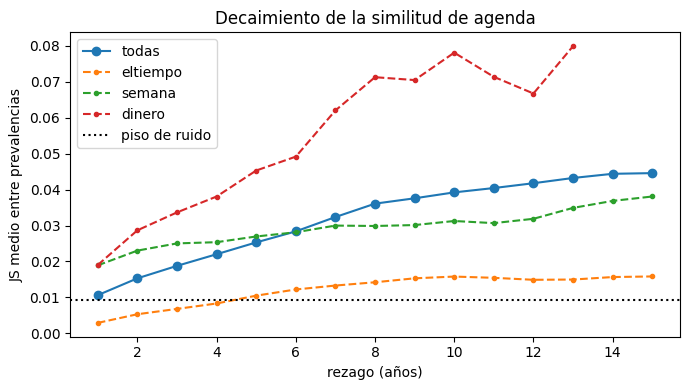

 rezago  js_medio  n_pares
      1    0.0106       29
      2    0.0153       28
      3    0.0188       27
      4    0.0220       26
      5    0.0253       25
      6    0.0284       24
      7    0.0324       23
      8    0.0361       22
      9    0.0376       21
     10    0.0392       20
     11    0.0404       19
     12    0.0418       18
     13    0.0432       17
     14    0.0444       16
     15    0.0446       15


In [ ]:
# Curva de decaimiento por rezago: si la agenda fuera estable, la divergencia no crece con el rezago
def js_media_rezago(P, lagmax=15):
    out = []
    for L in range(1, lagmax + 1):
        d = [js_div(P.loc[y].values, P.loc[y + L].values) for y in YEARS if y + L <= 2011 and not P.loc[y].isna().any() and not P.loc[y + L].isna().any()]
        out.append((L, np.mean(d) if d else np.nan, len(d)))
    return pd.DataFrame(out, columns=["rezago", "js_medio", "n_pares"])
Pm_all = P_all.copy(); Pm_all[n_ok < MIN_N] = np.nan
lag_all = js_media_rezago(Pm_all)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lag_all.rezago, lag_all.js_medio, "o-", label="todas")
for f, (P, n) in P_src.items():
    P.columns = topic_names
    l = js_media_rezago(P)
    if l.js_medio.notna().sum() >= 3: ax.plot(l.rezago, l.js_medio, "o--", ms=3, label=f)
if len(TR["todas"]): ax.axhline(TR["todas"].nulo_media.mean(), color="k", ls=":", label="piso de ruido")
ax.set_xlabel("rezago (años)"); ax.set_ylabel("JS medio entre prevalencias"); ax.set_title("Decaimiento de la similitud de agenda"); ax.legend()
savefig("fig_decaimiento_rezago.png", results); lag_all.round(4).to_csv(results / "decaimiento_rezago.csv", index=False)
print(lag_all.round(4).to_string(index=False))

**Cómo leer esto.** (i) Si el JS observado a rezago 1 queda dentro del piso de ruido, la agenda año a año es indistinguible del azar; (ii) si el JS **crece con el rezago** sin saturarse, hay **deriva gradual** (cambio acumulativo, sin saltos); (iii) si crece y luego se estabiliza, hay **regímenes**. Los puntos de cambio (siguiente sección) distinguen saltos de deriva.

## 6. ¿Cuándo cambia? Puntos de cambio sobre la serie de prevalencias
Se aplica **segmentación binaria** sobre la serie anual de prevalencias (transformación raíz cuadrada ≈ distancia de Hellinger, coherente con JS), con coste de mínimos cuadrados **ponderado por el N de cada año**. El umbral de cada división se calibra con un **modelo nulo** (barajar el orden de los años 200 veces y tomar el percentil 95 de la ganancia máxima), de modo que *no hay un porcentaje fijo de años marcados por construcción* (el defecto de la Entrega 1).

In [ ]:
def wsse(M, w):
    mu = (M * w[:, None]).sum(0) / w.sum(); return (w * ((M - mu) ** 2).sum(1)).sum()
def best_split(M, w, min_seg):
    n = len(M); tot = wsse(M, w); best = (0.0, None)
    for s in range(min_seg, n - min_seg + 1):
        g = tot - wsse(M[:s], w[:s]) - wsse(M[s:], w[s:])
        if g > best[0]: best = (g, s)
    return best
def binseg(M, w, min_seg=2, B=200, q=0.95, seed=0):
    rg = np.random.default_rng(seed); cps = []; stack = [(0, len(M))]
    while stack:
        lo, hi = stack.pop()
        if hi - lo < 2 * min_seg: continue
        g, s = best_split(M[lo:hi], w[lo:hi], min_seg)
        if s is None: continue
        gains = []
        for _ in range(B):
            p = rg.permutation(hi - lo); gains.append(best_split(M[lo:hi][p], w[lo:hi][p], min_seg)[0])
        thr = np.quantile(gains, q)
        if g > thr: cps.append((lo + s, g / thr)); stack += [(lo, lo + s), (lo + s, hi)]
    return sorted(cps)

def detectar(P, n, nombre, cap=3000, min_n=MIN_N):
    v = (n >= min_n) & P.notna().all(1)
    yrs = np.array(YEARS)[v.values]; M = np.sqrt(P[v].values.astype(float)); w = np.minimum(n[v].values, cap).astype(float)
    cps = binseg(M, w, B=200 if not FAST else 60)
    return {"variante": nombre, "años_validos": f"{yrs.min()}–{yrs.max()} ({len(yrs)})", "cambios": [(int(yrs[s]), round(float(f), 2)) for s, f in cps]}
# SERIE PRINCIPAL = El Tiempo (1990–2011): única fuente con cobertura continua y homogénea. El pooled mezcla un cambio de fuente en 1989→1990.
P_et, n_et = P_src["eltiempo"]
DET = [detectar(P_et, n_et, "El Tiempo (todos los docs)")]
# Series de CONTRASTE entre fuentes (independientes): se reportan aparte, no entran en el consenso
OTROS = []
for f in ["semana", "dinero"]:
    P, n = P_src[f]
    if (n >= MIN_N).sum() >= 8: OTROS.append(detectar(P, n, f"{f} (todos los docs)"))
P_s, n_s = P_src["semana"]; both = (n_et >= MIN_N) & (n_s >= MIN_N)
w_et = (srcs == "eltiempo").mean() / ((srcs == "eltiempo").mean() + (srcs == "semana").mean())
P_std = (w_et * P_et + (1 - w_et) * P_s).where(both); n_std = pd.concat([n_et, n_s], axis=1).min(1).where(both, 0)
OTROS.append(detectar(P_std, n_std, "estandarizada (El Tiempo + Semana, pesos fijos)"))
OTROS.append(detectar(Pm_all, n_ok, "pooled sin estandarizar (incluye cambio de fuente 1989→1990)"))
for d in DET + OTROS: print(d["variante"], "|", d["años_validos"], "| inicio de régimen (fuerza=ganancia/umbral):", d["cambios"])

El Tiempo (todos los docs) | 1990–2011 (22) | inicio de régimen (fuerza=ganancia/umbral): [(1995, 1.75), (2000, 1.38), (2006, 2.04)]
semana (todos los docs) | 1982–2011 (30) | inicio de régimen (fuerza=ganancia/umbral): [(1986, 1.17), (1994, 1.2), (1998, 1.82), (2006, 1.04), (2008, 1.71)]
dinero (todos los docs) | 1998–2011 (13) | inicio de régimen (fuerza=ganancia/umbral): [(2007, 1.24)]
estandarizada (El Tiempo + Semana, pesos fijos) | 1990–2011 (22) | inicio de régimen (fuerza=ganancia/umbral): [(1995, 1.28), (1999, 1.77), (2002, 1.0), (2006, 1.89)]
pooled sin estandarizar (incluye cambio de fuente 1989→1990) | 1982–2011 (30) | inicio de régimen (fuerza=ganancia/umbral): [(1986, 1.15), (1990, 1.41), (1992, 1.0), (1995, 1.67), (1999, 1.37), (2001, 1.0), (2006, 1.58)]


### Robustez
Los puntos de cambio solo son creíbles si **sobreviven** a decisiones arbitrarias del análisis: otra semilla de NMF, otro K, quitar entidades. Las variantes usan solo documentos de **El Tiempo** de la muestra balanceada por año (`CAP_PER_YEAR` docs/año), así que sus N son menores; el análisis principal usa todos los documentos de El Tiempo. El **consenso** se mide solo entre estas variantes; Semana, Dinero y la serie estandarizada se usan como **contraste independiente**.

In [ ]:
def prev_F(W, idx, src="eltiempo"):
    sel = (srcs[idx] == src) if src else np.ones(len(idx), bool)
    W = W[sel]; idx = idx[sel]
    r = W.sum(1); okf = r > 0; T = np.zeros_like(W); T[okf] = W[okf] / r[okf, None]
    P = pd.DataFrame(T[okf]); P["año"] = years[idx][okf]; g = P.groupby("año")
    return g.mean().reindex(YEARS), g.size().reindex(YEARS, fill_value=0)
for (K, seed), (m, W) in fits.items():
    if K == K_STAR and seed == 1: P, n = prev_F(W, F_idx); DET.append(detectar(P, n, f"semilla 1 (K={K})"))
    elif seed == 0 and K != K_STAR: P, n = prev_F(W, F_idx); DET.append(detectar(P, n, f"K={K}"))
# Sin entidades
tf2 = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=MIN_DF, max_df=MAX_DF, max_features=MAX_FEAT, sublinear_tf=True)
X2 = tf2.fit_transform([docs_noent[i] for i in F_idx])
m2 = NMF(n_components=K_STAR, init="nndsvda", random_state=0, max_iter=150, tol=1e-3); W2 = m2.fit_transform(X2)
P, n = prev_F(W2, F_idx); DET.append(detectar(P, n, "sin entidades (nombres propios)"))
robust = pd.DataFrame([{"variante": d["variante"], "años_validos": d["años_validos"], "cambios (año inicio régimen)": ", ".join(str(a) for a, _ in d["cambios"]) or "—"} for d in DET])
print(robust.to_string(index=False)); robust.to_csv(results / "robustez_cambios.csv", index=False)

                       variante   años_validos cambios (año inicio régimen)
     El Tiempo (todos los docs) 1990–2011 (22)             1995, 2000, 2006
                           K=15 1990–2011 (22)       1992, 1995, 2000, 2006
                           K=20 1990–2011 (22)             1995, 2000, 2006
                           K=30 1990–2011 (22)             1995, 1999, 2006
               semilla 1 (K=40) 1990–2011 (22)             1995, 2000, 2006
sin entidades (nombres propios) 1990–2011 (22)       1995, 1999, 2002, 2006


 año  variantes_con_cambio  de  soporte
1992                     1   6     0.17
1995                     6   6     1.00
1999                     6   6     1.00
2000                     6   6     1.00
2002                     1   6     0.17
2006                     6   6     1.00

Cambios con soporte ≥50% de las variantes (consenso, El Tiempo): [1995, 1999, 2006]

Contraste con otras series (¿aparece un cambio a ±1 año?):
  1995: {'semana': True, 'dinero': False, 'estandarizada': True, 'pooled sin estandarizar': True}
  1999: {'semana': True, 'dinero': False, 'estandarizada': True, 'pooled sin estandarizar': True}
  2006: {'semana': True, 'dinero': True, 'estandarizada': True, 'pooled sin estandarizar': True}
                                                    variante   años_validos                                  cambios
                                     semana (todos los docs) 1982–2011 (30)             1986, 1994, 1998, 2006, 2008
                                     dinero (tod

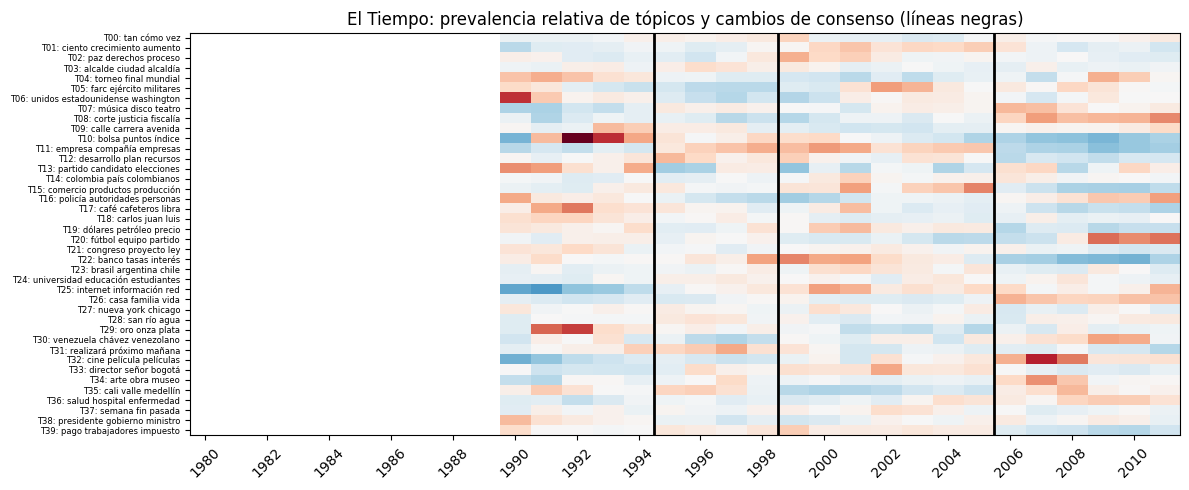

In [ ]:
# Soporte: para cada año candidato (de cualquier variante), en cuántas variantes aparece un cambio a ±1 año
cands = sorted({a for d in DET for a, _ in d["cambios"]})
sup = []
for c in cands:
    n_sup = sum(any(abs(a - c) <= 1 for a, _ in d["cambios"]) for d in DET)
    sup.append({"año": c, "variantes_con_cambio": n_sup, "de": len(DET), "soporte": n_sup / len(DET)})
sup = pd.DataFrame(sup)
# colapsar candidatos contiguos: quedarse con el de mayor soporte
sup = sup.sort_values(["soporte", "año"], ascending=[False, True]); keep = []
for _, r in sup.iterrows():
    if all(abs(r["año"] - k) > 1 for k in keep): keep.append(int(r["año"]))
CONSENSO = sorted([k for k in keep if sup.set_index("año").loc[k, "soporte"] >= 0.5])
print(sup.sort_values("año").round(2).to_string(index=False))
print("\nCambios con soporte ≥50% de las variantes (consenso, El Tiempo):", CONSENSO)
print("\nContraste con otras series (¿aparece un cambio a ±1 año?):")
for c in CONSENSO:
    print(f"  {c}:", {d["variante"].split(" (")[0]: any(abs(a - c) <= 1 for a, _ in d["cambios"]) for d in OTROS})
robust_otros = pd.DataFrame([{"variante": d["variante"], "años_validos": d["años_validos"], "cambios": ", ".join(str(a) for a, _ in d["cambios"]) or "—"} for d in OTROS]); print(robust_otros.to_string(index=False))
robust_otros.to_csv(results / "cambios_otras_series.csv", index=False)
sup.sort_values("año").to_csv(results / "soporte_cambios.csv", index=False)
fig, ax = plt.subplots(figsize=(12, 5))
Pet = P_et.copy(); Pet.columns = topic_names; Pet[n_et < MIN_N] = np.nan
ax.imshow((Pet / Pet.mean()).T.values, aspect="auto", cmap="RdBu_r", vmin=0, vmax=2)
for c in CONSENSO: ax.axvline(c - 1980 - 0.5, color="k", lw=2)
ax.set_yticks(range(K_STAR)); ax.set_yticklabels(topic_names, fontsize=6); ax.set_xticks(range(0, 32, 2)); ax.set_xticklabels(YEARS[::2], rotation=45)
ax.set_title("El Tiempo: prevalencia relativa de tópicos y cambios de consenso (líneas negras)"); savefig("fig_cambios_consenso.png", results)

## 7. Contraste con coyunturas históricas (último paso)
La lista de eventos se **congeló antes de mirar los resultados** (se redactó con la propuesta metodológica y no se modifica). Se mide cuántos cambios de consenso caen a ±1 año de un evento, y se compara con lo que se esperaría **al azar** (mismo número de cambios en años al azar). Con una ventana de ±1 año y ~8 eventos, una fracción alta de los años ya cae cerca de algún evento: por eso la línea base aleatoria es indispensable.

In [ ]:
# LISTA CONGELADA (no editar después de ver resultados)
EVENTOS = {1985: "Toma del Palacio de Justicia / Armero", 1989: "Asesinato de Galán; narcoterrorismo", 1991: "Constitución de 1991 / apertura económica",
           1993: "Muerte de Pablo Escobar", 1996: "Proceso 8000", 1998: "Pastrana, zona de distensión del Caguán", 2002: "Uribe y 'seguridad democrática'",
           2006: "Reelección de Uribe / parapolítica", 2010: "Santos / ola invernal"}
valid_years = [int(y) for y in YEARS if n_et[y] >= MIN_N]
def aciertos(cambios, ventana=1): return sum(any(abs(c - e) <= ventana for e in EVENTOS) for c in cambios)
rg = np.random.default_rng(SEED); nc = len(CONSENSO); obs = aciertos(CONSENSO)
base = np.array([aciertos(rg.choice(valid_years[2:-1], size=nc, replace=False)) for _ in range(5000)]) if nc and len(valid_years) > nc + 3 else np.array([])
print("Cambios de consenso:", CONSENSO)
for c in CONSENSO:
    cerca = [f"{e}: {t}" for e, t in EVENTOS.items() if abs(c - e) <= 1]
    print(f"  {c}  →  evento cercano (±1 año): {cerca if cerca else 'ninguno'}")
print("Eventos con un cambio a ±1 año:", [e for e in EVENTOS if any(abs(c - e) <= 1 for c in CONSENSO)])
if len(base): print(f"Aciertos observados: {obs}/{nc} | esperados al azar: {base.mean():.2f}/{nc} | P(azar ≥ observado) = {(base >= obs).mean():.3f}")

Cambios de consenso: [1995, 1999, 2006]
  1995  →  evento cercano (±1 año): ['1996: Proceso 8000']
  1999  →  evento cercano (±1 año): ['1998: Pastrana, zona de distensión del Caguán']
  2006  →  evento cercano (±1 año): ['2006: Reelección de Uribe / parapolítica']
Eventos con un cambio a ±1 año: [1996, 1998, 2006]
Aciertos observados: 3/3 | esperados al azar: 2.53/3 | P(azar ≥ observado) = 0.581


## 8. Limitaciones encontradas y mejoras propuestas
**Limitaciones (de diseño y de datos)**
1. **Fuente confundida con tiempo**: años 80 casi solo Semana, años 2000 casi solo El Tiempo. Los tests están estratificados por fuente y se reporta por fuente, pero la serie 1980–1989 tiene pocos documentos y poca potencia (años con N<`MIN_N` se excluyen).
2. **Resolución anual**: no detecta cambios más rápidos (elecciones, crisis); trimestral/mensual requiere más documentos por periodo.
3. **NMF unigrama sin lematización**: formas de una misma palabra se dispersan; los bigramas del notebook 05 no entran al modelo. Los tópicos pueden mezclar léxico de distintas secciones.
4. **Entidades**: nombres propios (Samper, Uribe…) pueden definir tópicos; la prueba "sin entidades" mide ese efecto, pero no lo elimina.
5. **K y semilla**: NMF no es determinista; se mitiga con coherencia + estabilidad, pero no se evalúa un modelo jerárquico.
6. **Composición de documentos**: la prensa mezcla secciones; un documento tiene varios temas; el nulo asume documentos intercambiables dentro de fuente (ignora autocorrelación dentro de una edición).
7. **Segmentación binaria** es voraz y asume saltos en media; la **deriva gradual** se descompone en escalones artificiales (se contrasta con la curva de decaimiento).
8. **Duplicados casi idénticos** (~1 %) siguen inflando algunos años.
9. **Recursos de cómputo**: Colab gratis limita el uso de lematización spaCy completa y embeddings sobre todo el corpus.

**Mejoras propuestas**
* Lematización spaCy (`es_core_news_sm`, sin parser/NER) en lotes con `nlp.pipe(n_process=2)`; bigramas NPMI como *features*.
* **BERTopic / clustering sobre embeddings** multilingües (en GPU) y comparación de la agenda resultante con la de NMF (criterio: coherencia + estabilidad + acuerdo de puntos de cambio).
* **Modelos con covariables** (STM / modelo de tópicos dinámico) que separan efecto de fuente y de tiempo en un solo modelo.
* PELT/Kleinberg a resolución trimestral con el mismo **nulo por permutación**; intervalos de confianza *bootstrap* sobre la prevalencia.
* Validación externa de tópicos con el léxico temático del notebook 05 y, si se consigue, con CAP codificado a mano en una muestra.
* Deduplicación robusta (MinHash con varios umbrales) antes de ajustar.

## 9. Exportar resultados

In [ ]:
out = pd.DataFrame(theta, columns=[f"T{k:02d}" for k in range(K_STAR)]).round(5)
out.insert(0, "id", df["id"].values); out.insert(1, "año", years); out.insert(2, "fuente", srcs); out["topico_dominante"] = dom
out.loc[~ok_doc, "topico_dominante"] = -1
out.to_csv(results / "theta_documentos.csv.gz", index=False)
resumen = {"K": K_STAR, "docs": int(len(df)), "años_validos": [int(y) for y in valid_years],
           "frac_transiciones_significativas": float((TR["todas"].p_bh < .05).mean()) if len(TR["todas"]) else None,
           "js_medio_rezago1": float(TR["todas"].js.mean()) if len(TR["todas"]) else None,
           "js_rezago1_eltiempo": float(TR["eltiempo"].js.mean()) if len(TR["eltiempo"]) else None,
           "ruido_medio": float(TR["todas"].nulo_media.mean()) if len(TR["todas"]) else None,
           "eta2_año": float((e_year * w_t).sum() / w_t.sum()), "eta2_fuente": float((e_src * w_t).sum() / w_t.sum()),
           "cambios_consenso_eltiempo": CONSENSO, "js_entre_fuentes": REF_FUENTES, "otras_series": {d["variante"]: [a for a, _ in d["cambios"]] for d in OTROS}, "variantes": [d["variante"] for d in DET]}
json.dump(resumen, open(results / "resumen_06.json", "w"), indent=2, ensure_ascii=False); print(json.dumps(resumen, indent=2, ensure_ascii=False))
print(sorted(p.name for p in results.iterdir()))
if utils.in_colab():
    import shutil; shutil.make_archive("/content/resultados_entrega2", "zip", str(results)); print("ZIP listo: /content/resultados_entrega2.zip (descárgalo desde el panel de archivos)")

{
  "K": 40,
  "docs": 91585,
  "años_validos": [
    1990,
    1991,
    1992,
    1993,
    1994,
    1995,
    1996,
    1997,
    1998,
    1999,
    2000,
    2001,
    2002,
    2003,
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011
  ],
  "frac_transiciones_significativas": 0.7241379310344828,
  "js_medio_rezago1": 0.010635403213764404,
  "js_rezago1_eltiempo": 0.002929718939873808,
  "ruido_medio": 0.00926763249935917,
  "eta2_año": 0.004067731910140659,
  "eta2_fuente": 0.005822257049659878,
  "cambios_consenso_eltiempo": [
    1995,
    1999,
    2006
  ],
  "js_entre_fuentes": 0.049698240706909425,
  "otras_series": {
    "semana (todos los docs)": [
      1986,
      1994,
      1998,
      2006,
      2008
    ],
    "dinero (todos los docs)": [
      2007
    ],
    "estandarizada (El Tiempo + Semana, pesos fijos)": [
      1995,
      1999,
      2002,
      2006
    ],
    "pooled sin estandarizar (incluye cambio de fuente 1989→1990)": [
  